100%|██████████| 9.91M/9.91M [00:00<00:00, 36.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.19MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 790kB/s]


[1, 200] loss: 0.660
[1, 400] loss: 0.325
[1, 600] loss: 0.275
[1, 800] loss: 0.225
[1, 1000] loss: 0.211
[1, 1200] loss: 0.205
[1, 1400] loss: 0.171
[1, 1600] loss: 0.168
[1, 1800] loss: 0.146
[2, 200] loss: 0.141
[2, 400] loss: 0.117
[2, 600] loss: 0.129
[2, 800] loss: 0.129
[2, 1000] loss: 0.125
[2, 1200] loss: 0.116
[2, 1400] loss: 0.114
[2, 1600] loss: 0.127
[2, 1800] loss: 0.109
[3, 200] loss: 0.094
[3, 400] loss: 0.083
[3, 600] loss: 0.085
[3, 800] loss: 0.084
[3, 1000] loss: 0.104
[3, 1200] loss: 0.093
[3, 1400] loss: 0.092
[3, 1600] loss: 0.106
[3, 1800] loss: 0.112
[4, 200] loss: 0.072
[4, 400] loss: 0.062
[4, 600] loss: 0.080
[4, 800] loss: 0.066
[4, 1000] loss: 0.068
[4, 1200] loss: 0.092
[4, 1400] loss: 0.098
[4, 1600] loss: 0.091
[4, 1800] loss: 0.075
[5, 200] loss: 0.094
[5, 400] loss: 0.061
[5, 600] loss: 0.061
[5, 800] loss: 0.047
[5, 1000] loss: 0.053
[5, 1200] loss: 0.041
[5, 1400] loss: 0.079
[5, 1600] loss: 0.064
[5, 1800] loss: 0.057
[6, 200] loss: 0.050
[6, 400] 

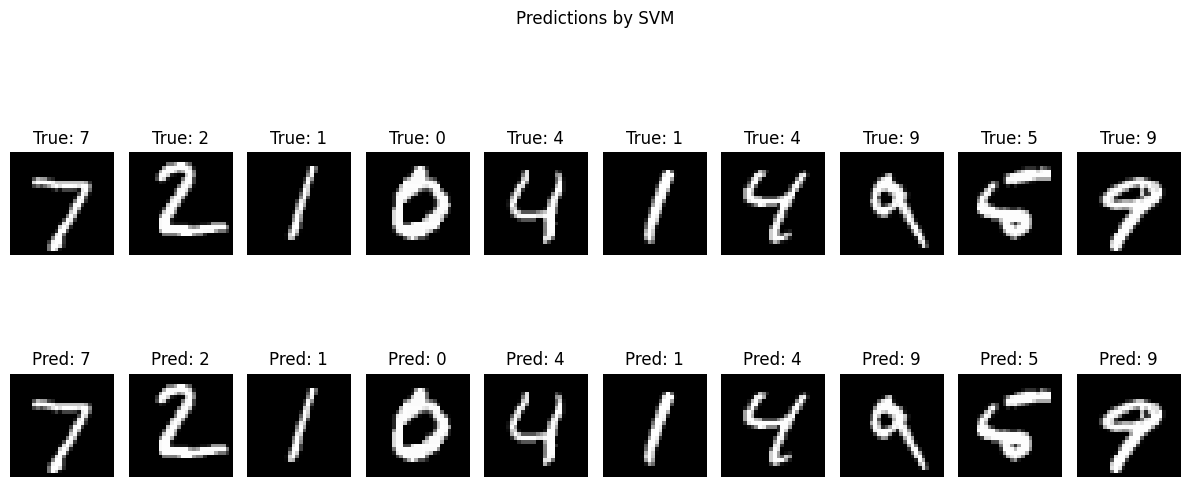

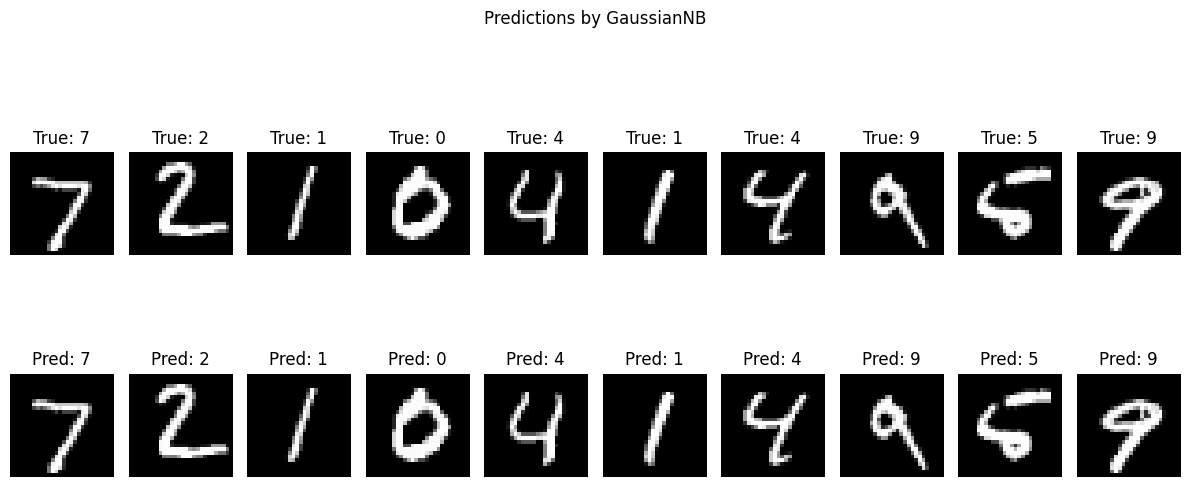

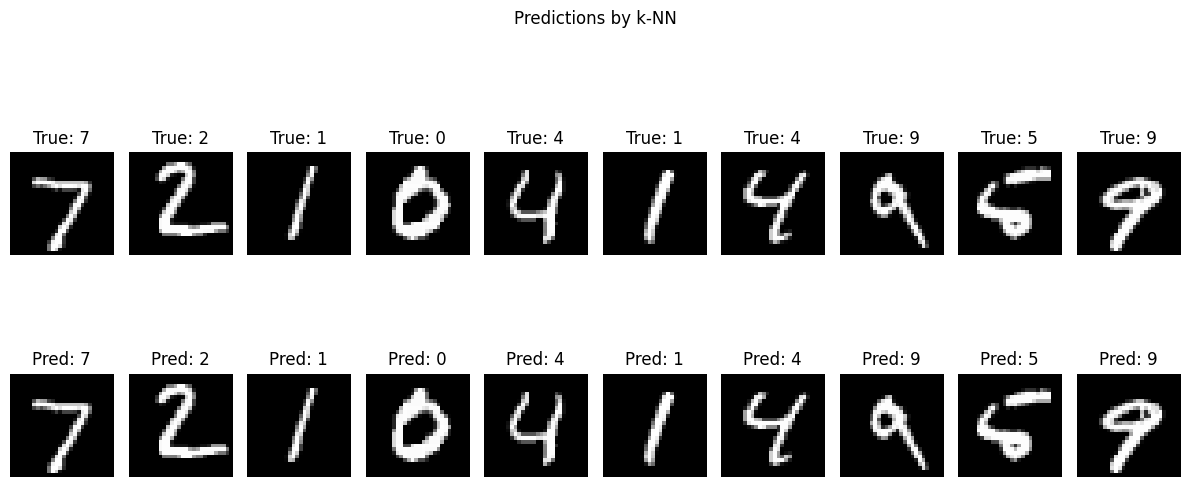

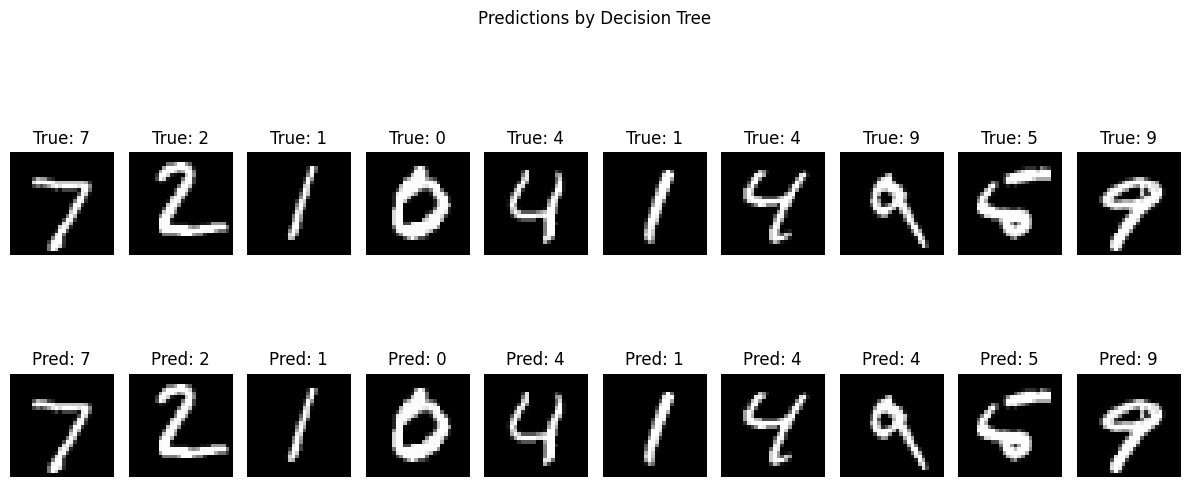

In [ ]:
# MNIST DATASET
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import numpy as np
from torch.utils.data import DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# Fourier Transform Defense Function
def fourier_transform_defense(img, low_freq=0.1, high_freq=0.9):
    img_fft = torch.fft.fft2(img)
    img_fft_shift = torch.fft.fftshift(img_fft)

    rows, cols = img.shape[-2], img.shape[-1]
    crow, ccol = rows // 2, cols // 2
    radius = int(min(rows, cols) * high_freq)
    mask = torch.zeros_like(img_fft_shift, dtype=torch.complex64)
    mask[crow-radius:crow+radius, ccol-radius:ccol+radius] = 1

    img_fft_shift_masked = img_fft_shift * mask
    img_fft_inv = torch.fft.ifftshift(img_fft_shift_masked)
    img_cleaned = torch.fft.ifft2(img_fft_inv)
    img_cleaned = torch.abs(img_cleaned)
    img_cleaned = torch.clamp(img_cleaned, 0, 1)
    return img_cleaned

# Feature Space Attack
def feature_space_attack(features, epsilon=0.1):
    perturbation = epsilon * torch.sign(torch.randn_like(features))
    adversarial_features = features + perturbation
    return adversarial_features

# Load original images for display
original_transform = transforms.ToTensor()
original_testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=original_transform)

# Transforms for ResNet18 input
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=32, shuffle=False, num_workers=2)
original_loader = DataLoader(original_testset, batch_size=32, shuffle=False, num_workers=2)

# ResNet Feature Extractor
class ResNetFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        pretrained_model = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.feature_extractor = nn.Sequential(*list(pretrained_model.children())[:-1])
        self.fc = nn.Linear(512, 10)

    def forward(self, x):
        features = self.feature_extractor(x)
        features = features.view(features.size(0), -1)
        logits = self.fc(features)
        return logits, features

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNetFeatureExtractor().to(device)

for param in model.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(10):
    model.train()
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Apply Fourier Transform defense to the images
        inputs_defended = torch.stack([fourier_transform_defense(img) for img in inputs])

        optimizer.zero_grad()
        outputs, _ = model(inputs_defended)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 200 == 199:
            print(f"[{epoch + 1}, {i + 1}] loss: {running_loss / 200:.3f}")
            running_loss = 0.0

print("Finished Training")

# Feature Extraction with Attack
def extract_features_with_attack(model, dataloader, epsilon=0.1):
    features, labels = [], []
    model.eval()
    with torch.no_grad():
        for images, targets in dataloader:
            images, targets = images.to(device), targets.to(device)

            images_defended = torch.stack([fourier_transform_defense(img) for img in images])

            _, feats = model(images_defended)
            adversarial_feats = feature_space_attack(feats, epsilon)
            features.append(adversarial_feats.cpu().numpy())
            labels.append(targets.cpu().numpy())
    return np.concatenate(features), np.concatenate(labels)

train_features, train_labels = extract_features_with_attack(model, trainloader)
test_features, test_labels = extract_features_with_attack(model, testloader)

# Classical ML Classifiers
svm_clf = SVC(kernel='rbf', C=1.0)
svm_clf.fit(train_features, train_labels)

gnb_clf = GaussianNB()
gnb_clf.fit(train_features, train_labels)

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(train_features, train_labels)

dt_clf = DecisionTreeClassifier(max_depth=15)
dt_clf.fit(train_features, train_labels)

# Accuracy
svm_acc = accuracy_score(test_labels, svm_clf.predict(test_features))
gnb_acc = accuracy_score(test_labels, gnb_clf.predict(test_features))
knn_acc = accuracy_score(test_labels, knn_clf.predict(test_features))
dt_acc = accuracy_score(test_labels, dt_clf.predict(test_features))

print(f"SVM Accuracy: {svm_acc * 100:.2f}%")
print(f"Gaussian Naive Bayes Accuracy: {gnb_acc * 100:.2f}%")
print(f"k-NN Accuracy: {knn_acc * 100:.2f}%")
print(f"Decision Tree Accuracy: {dt_acc * 100:.2f}%")

# Visualization of predictions
def display_predictions(original_images, labels, predictions, classifier_name, classes):
    plt.figure(figsize=(12, 6))
    for i in range(10):
        img = original_images[i].clone().detach().cpu().squeeze(0)
        plt.subplot(2, 10, i + 1)
        plt.imshow(img.numpy(), cmap='gray')
        plt.title(f"True: {classes[labels[i]]}")
        plt.axis("off")

        plt.subplot(2, 10, i + 11)
        plt.imshow(img.numpy(), cmap='gray')
        plt.title(f"Pred: {classes[predictions[i]]}")
        plt.axis("off")

    plt.suptitle(f"Predictions by {classifier_name}")
    plt.tight_layout()
    plt.show()

# Sample Prediction with adversarial features
dataiter = iter(testloader)
original_iter = iter(original_loader)

images, labels = next(dataiter)
orig_images, _ = next(original_iter)

images, labels = images.to(device), labels.to(device)
model.eval()
with torch.no_grad():
    images_defended = torch.stack([fourier_transform_defense(img) for img in images])
    _, feats = model(images_defended)
    adversarial_feats = feature_space_attack(feats, epsilon=0.1)
    adversarial_feats = adversarial_feats.cpu().numpy()

batch_labels = labels.cpu().numpy()
classes = [str(i) for i in range(10)]

# Display predictions
display_predictions(orig_images, batch_labels, svm_clf.predict(adversarial_feats), "SVM", classes)
display_predictions(orig_images, batch_labels, gnb_clf.predict(adversarial_feats), "GaussianNB", classes)
display_predictions(orig_images, batch_labels, knn_clf.predict(adversarial_feats), "k-NN", classes)
display_predictions(orig_images, batch_labels, dt_clf.predict(adversarial_feats), "Decision Tree", classes)


Using: Tesla T4
Training...
Epoch [1/25] Loss: 0.3198
Epoch [2/25] Loss: 0.1252
Epoch [3/25] Loss: 0.0691
Epoch [4/25] Loss: 0.0534
Epoch [5/25] Loss: 0.0440
Epoch [6/25] Loss: 0.0392
Epoch [7/25] Loss: 0.0360
Epoch [8/25] Loss: 0.0308
Epoch [9/25] Loss: 0.0257
Epoch [10/25] Loss: 0.0264
Epoch [11/25] Loss: 0.0266
Epoch [12/25] Loss: 0.0217
Epoch [13/25] Loss: 0.0202
Epoch [14/25] Loss: 0.0215
Epoch [15/25] Loss: 0.0251
Epoch [16/25] Loss: 0.0151
Epoch [17/25] Loss: 0.0175
Epoch [18/25] Loss: 0.0210
Epoch [19/25] Loss: 0.0155
Epoch [20/25] Loss: 0.0139
Epoch [21/25] Loss: 0.0137
Epoch [22/25] Loss: 0.0166
Epoch [23/25] Loss: 0.0156
Epoch [24/25] Loss: 0.0129
Epoch [25/25] Loss: 0.0146
Training completed.

Training Classical Classifiers...
All classifiers trained.
SVM Accuracy: 93.46%
Naive Bayes Accuracy: 91.33%
k-NN Accuracy: 93.26%
Decision Tree Accuracy: 90.58%


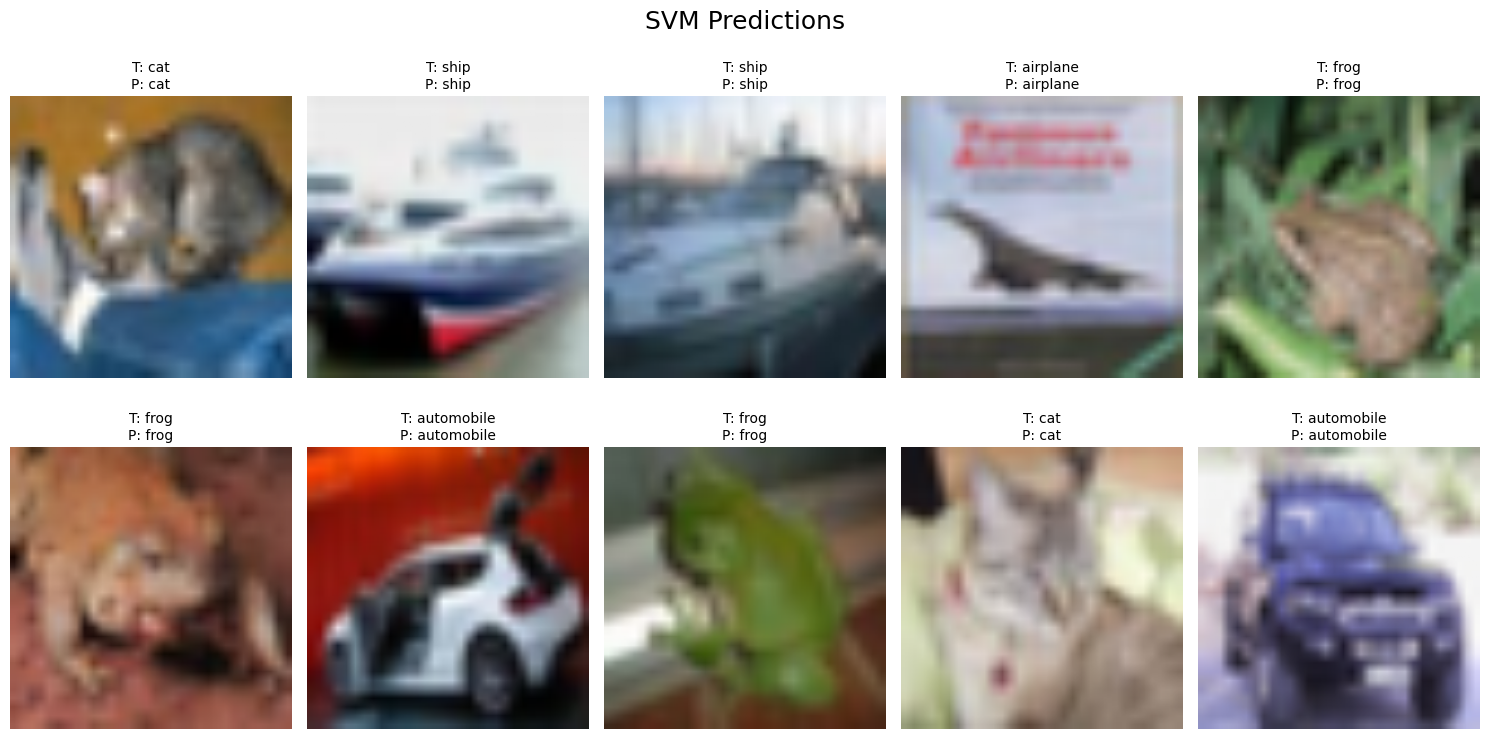

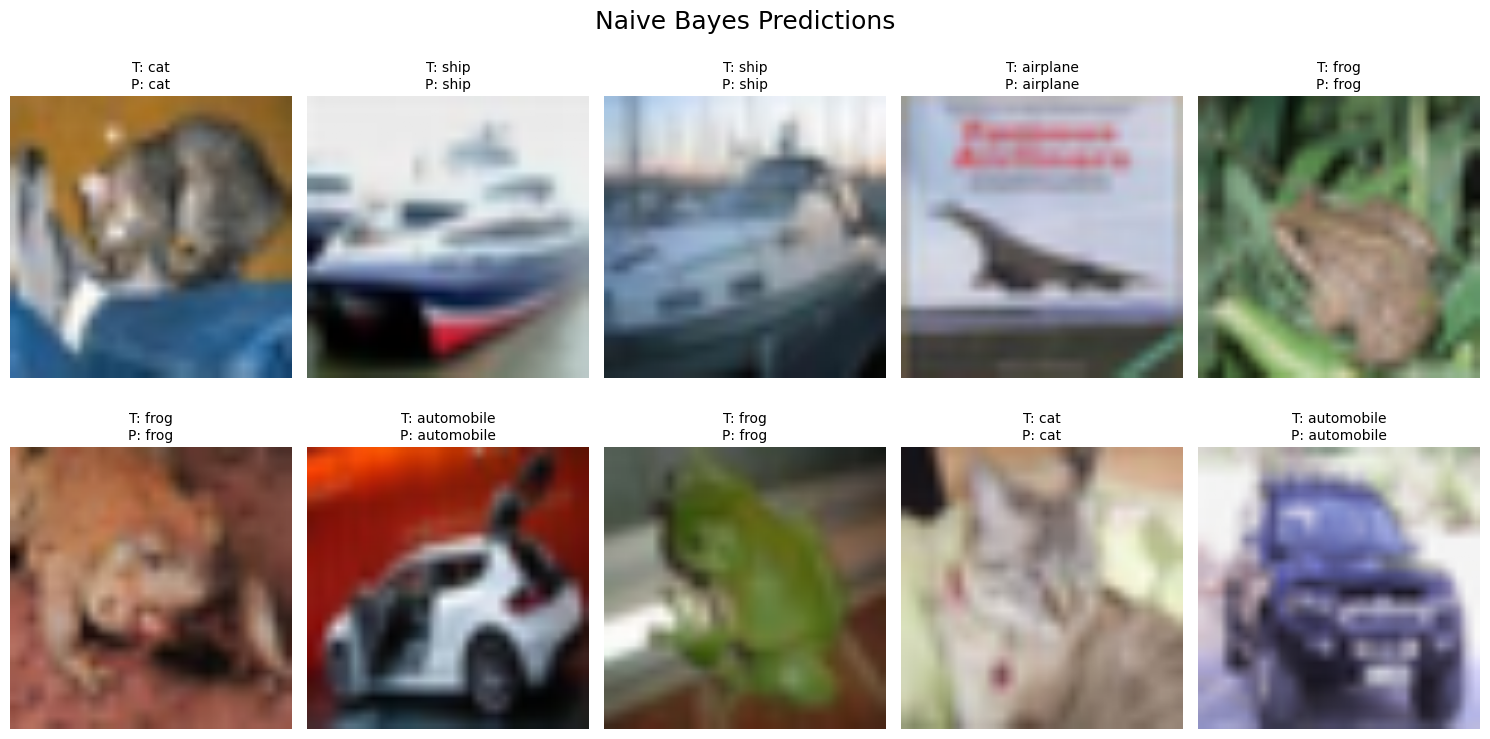

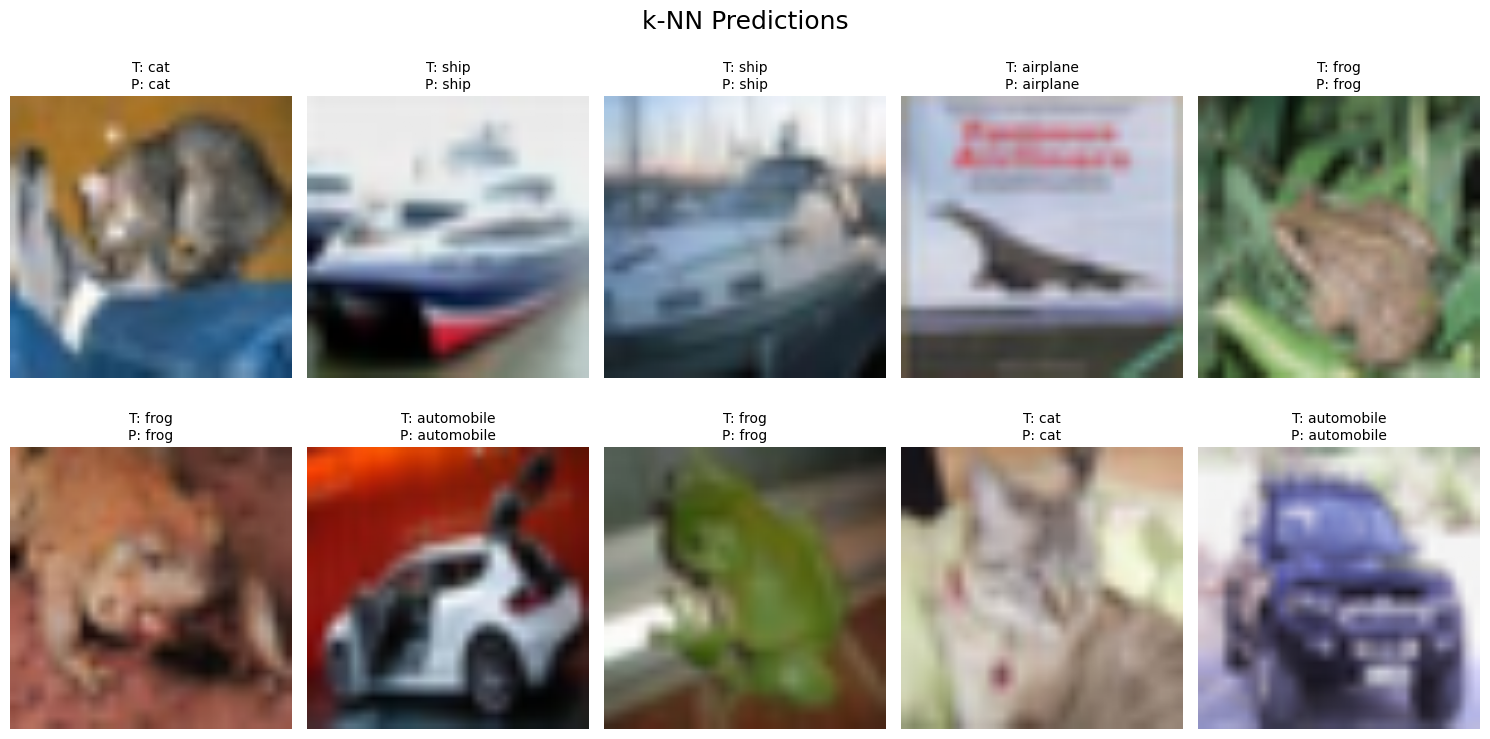

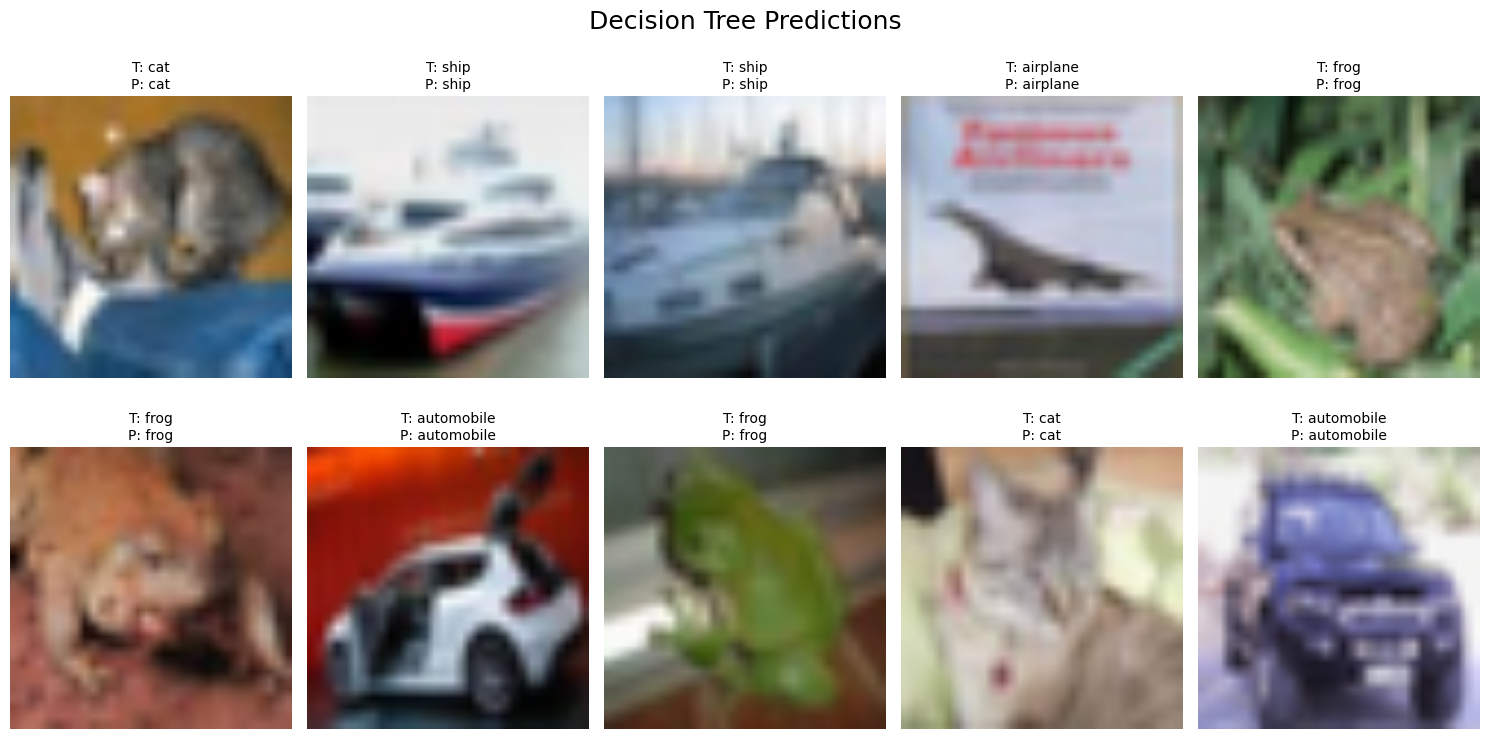


Summary of Classifier Accuracies:
SVM Accuracy: 93.46%
Naive Bayes Accuracy: 91.33%
k-NN Accuracy: 93.26%
Decision Tree Accuracy: 90.58%


In [ ]:
#CIFAR 10 DATASET
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from torchvision.models import resnet18

# ================================
# Device Setup
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# ================================
# Transforms
# ================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# ================================
# Load CIFAR-10
# ================================
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# ================================
# Better Fourier Defense
# ================================
def apply_fft_defense(features):
    fft_features = np.fft.fft(features, axis=1)
    keep = int(fft_features.shape[1] * 0.2)  # Keep 20% low-frequency
    fft_features[:, keep:] = 0
    recovered = np.fft.ifft(fft_features, axis=1)
    return np.real(recovered)

# ================================
# Light Feature Space Attack
# ================================
def feature_space_attack(features, epsilon=0.00001):
    perturb = np.random.normal(0, epsilon, features.shape)
    return features + perturb

# ================================
# ResNet18 Feature Extractor
# ================================
class ResNetFeatureExtractor(nn.Module):
    def __init__(self):
        super(ResNetFeatureExtractor, self).__init__()
        base = resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
        for param in base.parameters():
            param.requires_grad = True  # Full fine-tune
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
        self.fc = nn.Linear(512, 10)

    def forward(self, x):
        x = self.feature_extractor(x)
        features = x.view(x.size(0), -1)
        logits = self.fc(features)
        return logits, features

model = ResNetFeatureExtractor().to(device)

# ================================
# Training
# ================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

print("Training...")
epochs = 20
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs, _ = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(trainloader):.4f}")
print("Training completed.")

# ================================
# Extract Features
# ================================
def extract_features(model, dataloader):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            _, feats = model(inputs)
            features.append(feats.cpu().numpy())
            labels.append(targets.numpy())
    return np.concatenate(features), np.concatenate(labels)

train_features, train_labels = extract_features(model, trainloader)
test_features, test_labels = extract_features(model, testloader)

# ================================
# Attack + Defense
# ================================
adv_train_features = apply_fft_defense(feature_space_attack(train_features))
adv_test_features = apply_fft_defense(feature_space_attack(test_features))

# ================================
# Train Classical Classifiers
# ================================
print("\nTraining Classical Classifiers...")
svm = SVC(kernel='rbf', C=30, gamma='scale').fit(adv_train_features, train_labels)
nb = GaussianNB().fit(adv_train_features, train_labels)
knn = KNeighborsClassifier(n_neighbors=3, weights='distance').fit(adv_train_features, train_labels)
dt = DecisionTreeClassifier(max_depth=40, min_samples_split=2).fit(adv_train_features, train_labels)
print("All classifiers trained.")

# ================================
# Evaluation
# ================================
def evaluate(model, name):
    preds = model.predict(adv_test_features)
    acc = accuracy_score(test_labels, preds) * 100
    print(f"{name} Accuracy: {acc:.2f}%")
    return preds, acc

svm_preds, svm_acc = evaluate(svm, "SVM")
nb_preds, nb_acc = evaluate(nb, "Naive Bayes")
knn_preds, knn_acc = evaluate(knn, "k-NN")
dt_preds, dt_acc = evaluate(dt, "Decision Tree")

# ================================
# Visualization (Clear Images)
# ================================
classes = trainset.classes

def show_preds(images, labels, preds, title):
    plt.figure(figsize=(15, 8))
    for i in range(10):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = (img * 0.5) + 0.5  # Proper unnormalize
        img = np.clip(img, 0, 1)
        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.title(f"T: {classes[labels[i]]}\nP: {classes[preds[i]]}", fontsize=10)
        plt.axis("off")
    plt.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()

dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels

with torch.no_grad():
    _, feats = model(images)
    feats = feats.cpu().numpy()
    adv_feats = apply_fft_defense(feature_space_attack(feats))

show_preds(images, labels.cpu().numpy(), svm.predict(adv_feats), "SVM Predictions")
show_preds(images, labels.cpu().numpy(), nb.predict(adv_feats), "Naive Bayes Predictions")
show_preds(images, labels.cpu().numpy(), knn.predict(adv_feats), "k-NN Predictions")
show_preds(images, labels.cpu().numpy(), dt.predict(adv_feats), "Decision Tree Predictions")

# ================================
# Summary
# ================================
print("\nSummary of Classifier Accuracies:")
print(f"SVM Accuracy: {svm_acc:.2f}%")
print(f"Naive Bayes Accuracy: {nb_acc:.2f}%")
print(f"k-NN Accuracy: {knn_acc:.2f}%")
print(f"Decision Tree Accuracy: {dt_acc:.2f}%")


Using: Tesla T4


100%|██████████| 169M/169M [00:04<00:00, 40.7MB/s]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 145MB/s]



Training...
Epoch [1/30] Loss: 1.7456
Epoch [2/30] Loss: 0.8149
Epoch [3/30] Loss: 0.4537
Epoch [4/30] Loss: 0.2013
Epoch [5/30] Loss: 0.0776
Epoch [6/30] Loss: 0.0335
Epoch [7/30] Loss: 0.0183
Epoch [8/30] Loss: 0.0126
Epoch [9/30] Loss: 0.0099
Epoch [10/30] Loss: 0.0078
Epoch [11/30] Loss: 0.0065
Epoch [12/30] Loss: 0.0060
Epoch [13/30] Loss: 0.0055
Epoch [14/30] Loss: 0.0050
Epoch [15/30] Loss: 0.0048
Epoch [16/30] Loss: 0.0045
Epoch [17/30] Loss: 0.0043
Epoch [18/30] Loss: 0.0041
Epoch [19/30] Loss: 0.0039
Epoch [20/30] Loss: 0.0037
Epoch [21/30] Loss: 0.0035
Epoch [22/30] Loss: 0.0034
Epoch [23/30] Loss: 0.0033
Epoch [24/30] Loss: 0.0031
Epoch [25/30] Loss: 0.0032
Epoch [26/30] Loss: 0.0032
Epoch [27/30] Loss: 0.0031
Epoch [28/30] Loss: 0.0030
Epoch [29/30] Loss: 0.0030
Epoch [30/30] Loss: 0.0029
Training completed.

Applying PCA...
PCA completed.

Training Classical Classifiers...
All classifiers trained.

Evaluating...
SVM Accuracy: 73.13%
Naive Bayes Accuracy: 71.71%
k-NN Accu

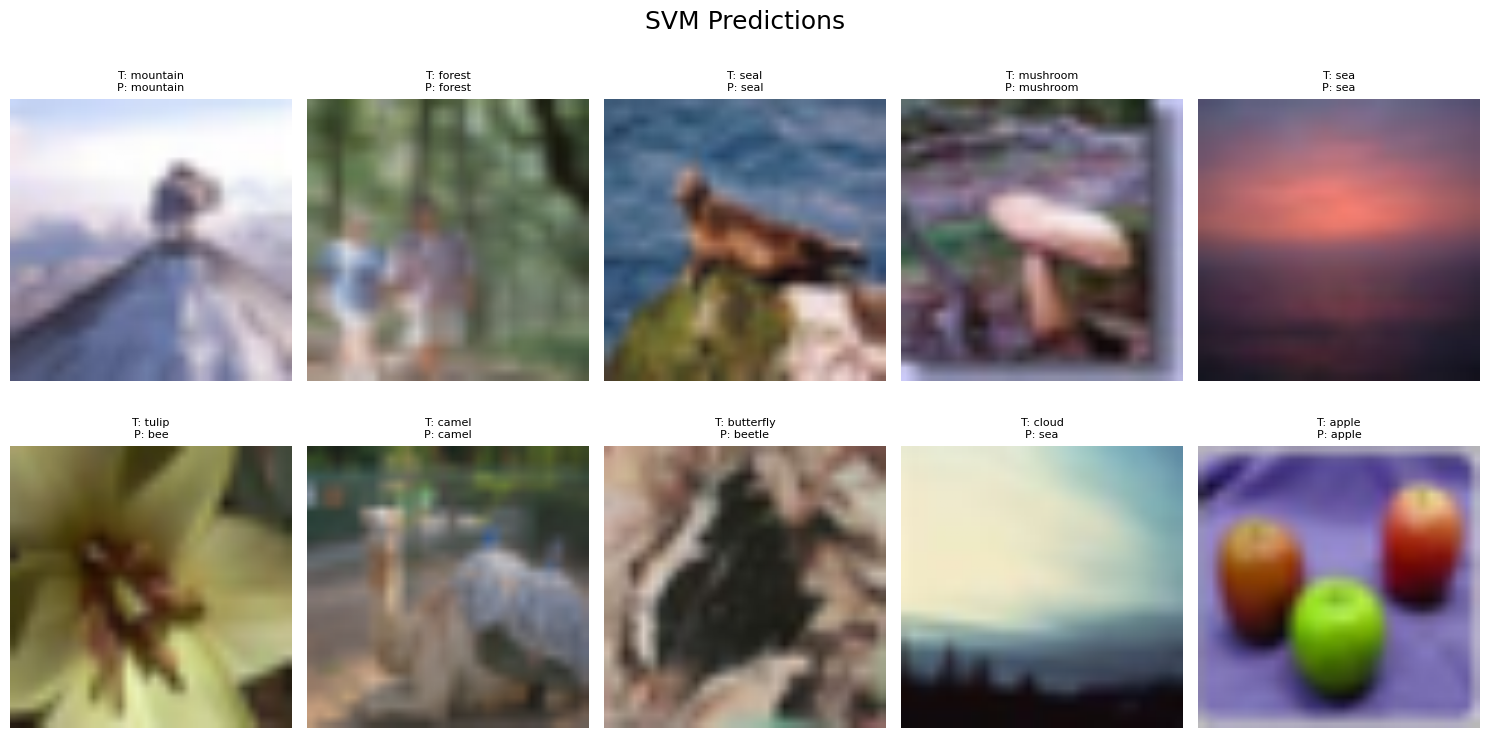

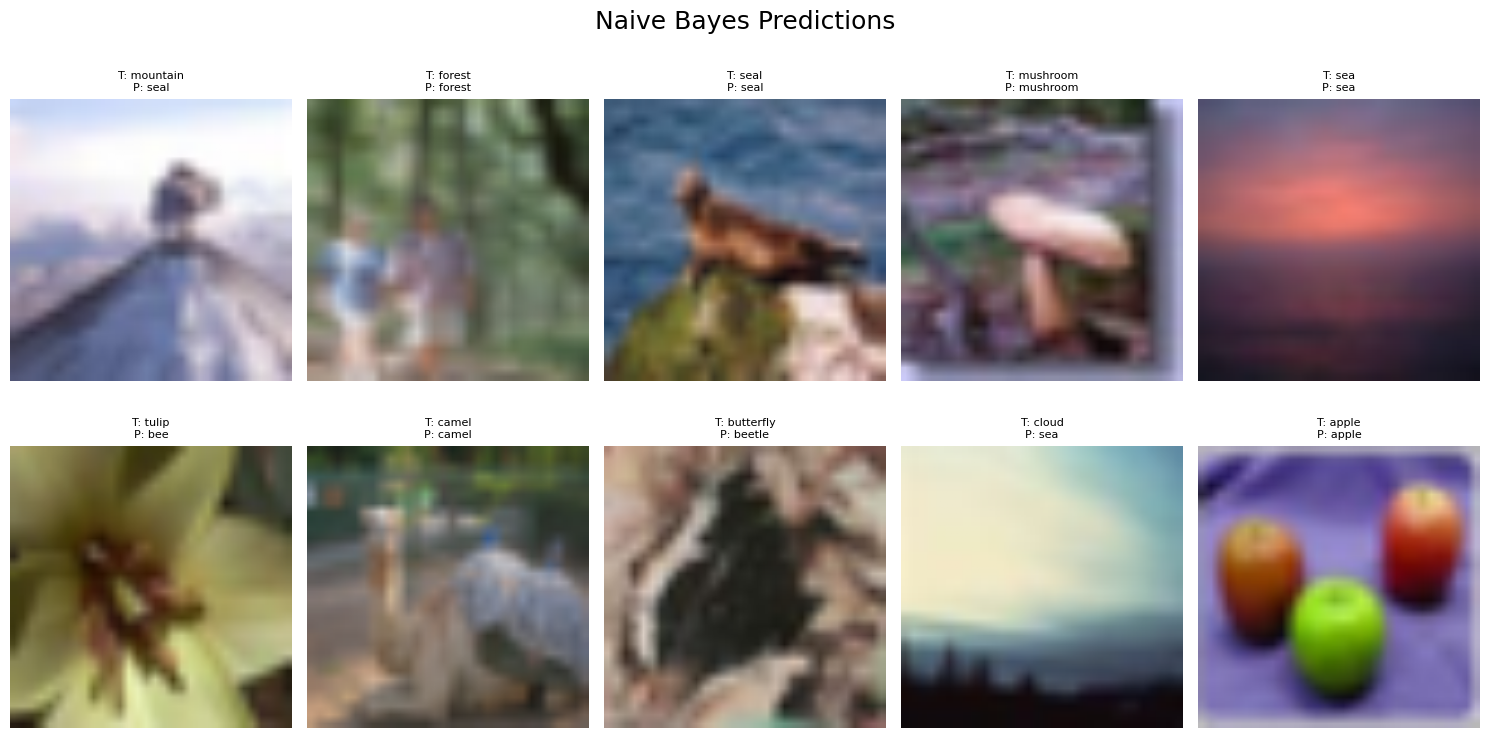

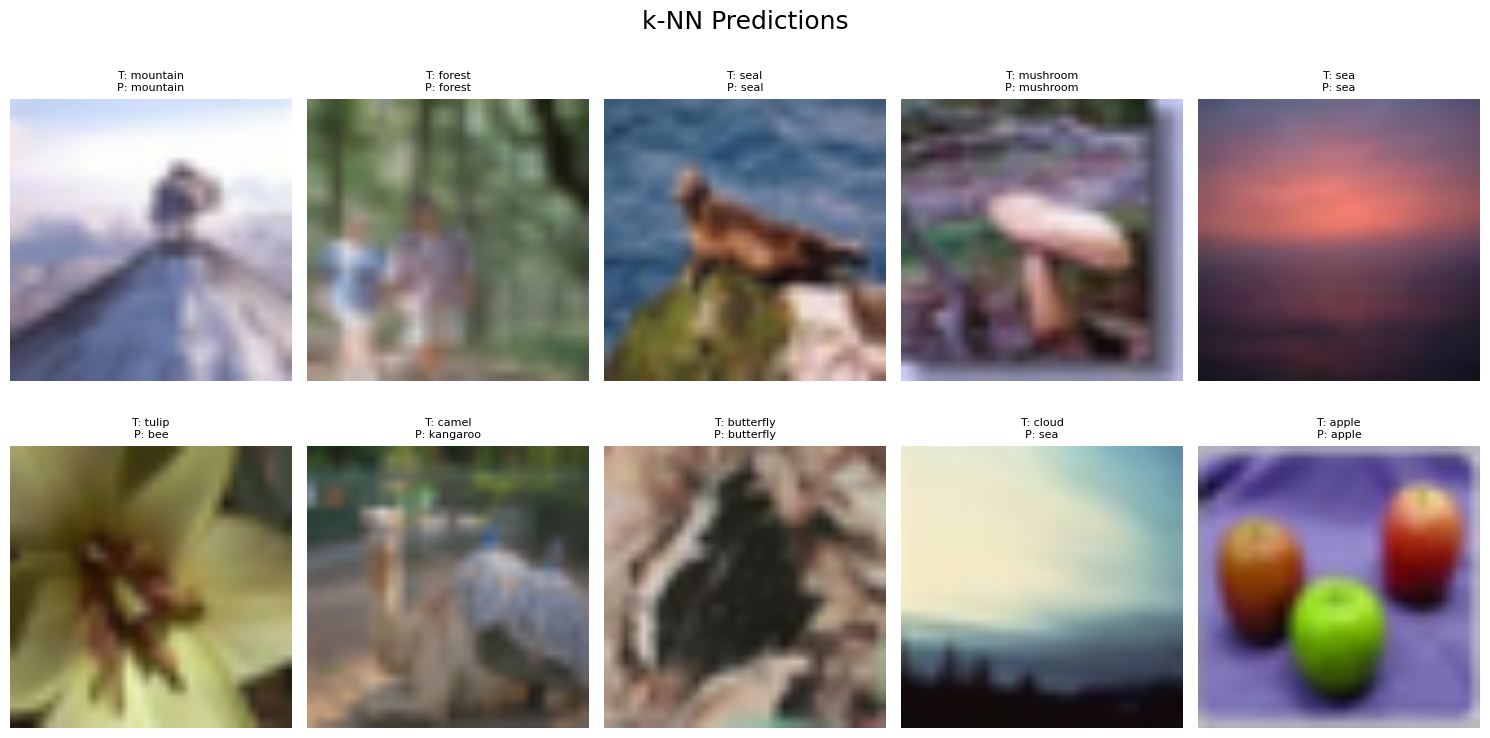

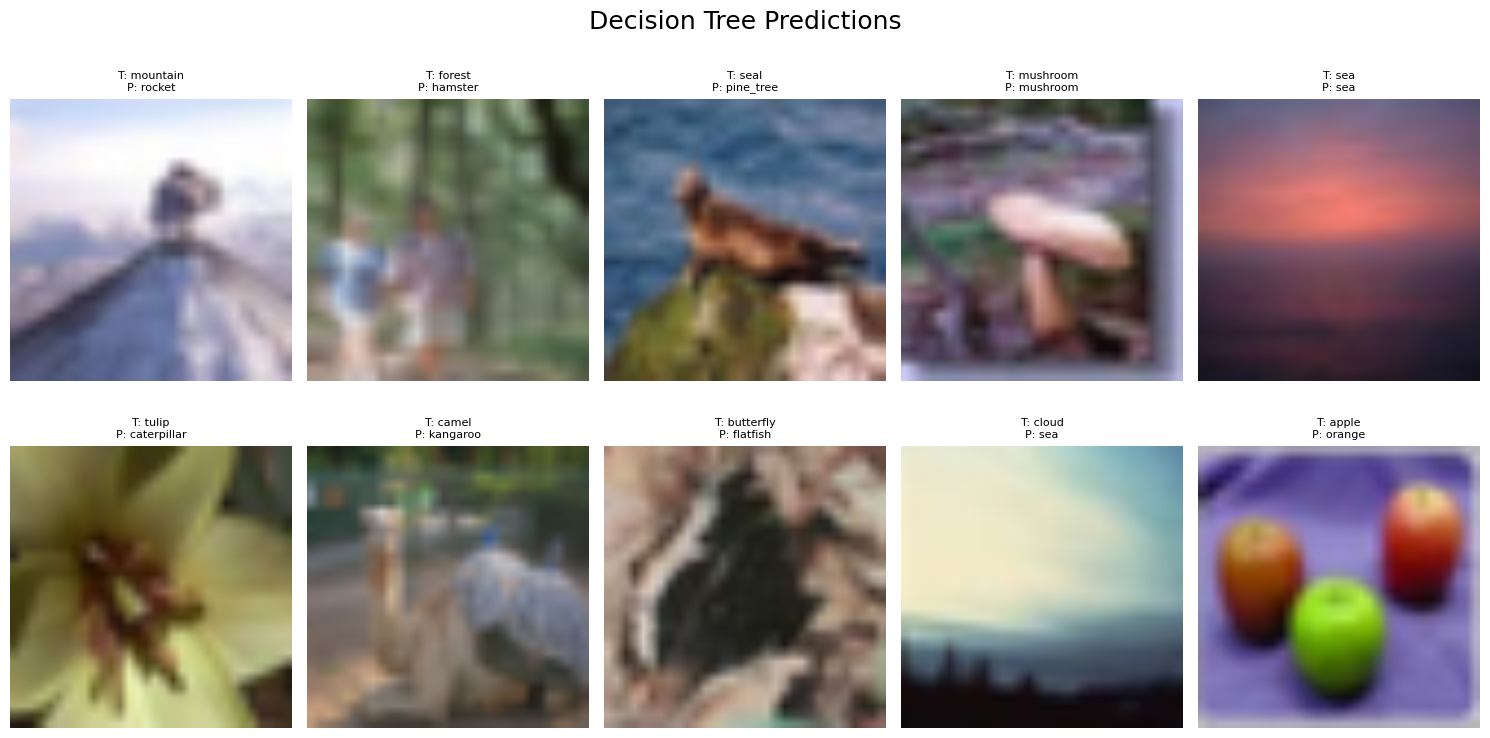


Summary of Classifier Accuracies:
SVM Accuracy: 73.13%
Naive Bayes Accuracy: 71.71%
k-NN Accuracy: 72.35%
Decision Tree Accuracy: 46.15%


In [ ]:
#CIFAR 100 DATASET
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader
from torchvision.models import resnet18

# ================================
# Device Setup
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# ================================
# Transforms
# ================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# ================================
# Load CIFAR-100
# ================================
trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# ================================
# Fourier Defense
# ================================
def apply_fft_defense(features, keep_ratio=0.6):  # Keep more information
    fft_features = np.fft.fft(features, axis=1)
    keep = int(fft_features.shape[1] * keep_ratio)
    fft_features[:, keep:] = 0
    recovered = np.fft.ifft(fft_features, axis=1)
    return np.real(recovered)

# ================================
# Feature Space Attack
# ================================
def feature_space_attack(features, epsilon=0.01):  # Stronger attack
    perturb = np.random.normal(0, epsilon, features.shape)
    return features + perturb

# ================================
# ResNet18 Feature Extractor
# ================================
class ResNetFeatureExtractor(nn.Module):
    def __init__(self):
        super(ResNetFeatureExtractor, self).__init__()
        base = resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
        for name, param in base.named_parameters():
            if 'layer4' not in name:
                param.requires_grad = False
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
        self.fc = nn.Linear(512, 100)

    def forward(self, x):
        x = self.feature_extractor(x)
        features = x.view(x.size(0), -1)
        logits = self.fc(features)
        return logits, features

model = ResNetFeatureExtractor().to(device)

# ================================
# Training
# ================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print("\nTraining...")
epochs = 30  # More epochs
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs, _ = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(trainloader):.4f}")
print("Training completed.")

# ================================
# Feature Extraction
# ================================
def extract_features(model, dataloader):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            _, feats = model(inputs)
            features.append(feats.cpu().numpy())
            labels.append(targets.numpy())
    return np.concatenate(features), np.concatenate(labels)

train_features, train_labels = extract_features(model, trainloader)
test_features, test_labels = extract_features(model, testloader)

# ================================
# Attack + Defense
# ================================
adv_train_features = apply_fft_defense(feature_space_attack(train_features))
adv_test_features = apply_fft_defense(feature_space_attack(test_features))

# ================================
# PCA for Speed
# ================================
print("\nApplying PCA...")
pca = PCA(n_components=256)  # Less compression
adv_train_features = pca.fit_transform(adv_train_features)
adv_test_features = pca.transform(adv_test_features)
print("PCA completed.")

# ================================
# Train Classifiers
# ================================
print("\nTraining Classical Classifiers...")
svm = SVC(kernel='rbf', C=100, gamma=0.01).fit(adv_train_features, train_labels)
nb = GaussianNB().fit(adv_train_features, train_labels)
knn = KNeighborsClassifier(n_neighbors=3, weights='distance').fit(adv_train_features, train_labels)
dt = DecisionTreeClassifier(max_depth=60, min_samples_split=2).fit(adv_train_features, train_labels)
print("All classifiers trained.")

# ================================
# Evaluation
# ================================
def evaluate(model, name):
    preds = model.predict(adv_test_features)
    acc = accuracy_score(test_labels, preds) * 100
    print(f"{name} Accuracy: {acc:.2f}%")
    return preds, acc

print("\nEvaluating...")
svm_preds, svm_acc = evaluate(svm, "SVM")
nb_preds, nb_acc = evaluate(nb, "Naive Bayes")
knn_preds, knn_acc = evaluate(knn, "k-NN")
dt_preds, dt_acc = evaluate(dt, "Decision Tree")

# ================================
# Visualization
# ================================
classes = trainset.classes

def show_preds(images, labels, preds, title):
    plt.figure(figsize=(15, 8))
    for i in range(10):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = (img * 0.5) + 0.5  # unnormalize
        img = np.clip(img, 0, 1)
        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.title(f"T: {classes[labels[i]]}\nP: {classes[preds[i]]}", fontsize=8)
        plt.axis("off")
    plt.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()

dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels

with torch.no_grad():
    _, feats = model(images)
    feats = feats.cpu().numpy()
    feats = apply_fft_defense(feature_space_attack(feats))
    feats = pca.transform(feats)

show_preds(images, labels.cpu().numpy(), svm.predict(feats), "SVM Predictions")
show_preds(images, labels.cpu().numpy(), nb.predict(feats), "Naive Bayes Predictions")
show_preds(images, labels.cpu().numpy(), knn.predict(feats), "k-NN Predictions")
show_preds(images, labels.cpu().numpy(), dt.predict(feats), "Decision Tree Predictions")

# ================================
# Summary
# ================================
print("\nSummary of Classifier Accuracies:")
print(f"SVM Accuracy: {svm_acc:.2f}%")
print(f"Naive Bayes Accuracy: {nb_acc:.2f}%")
print(f"k-NN Accuracy: {knn_acc:.2f}%")
print(f"Decision Tree Accuracy: {dt_acc:.2f}%")
